In [1]:
districts_panel <- readRDS('data\\districts_panel.RDS')
series_codes <- read.csv('data\\IndoDapoerSeries.csv')

In [2]:
library(foreign)
library(tibble)
library(magrittr)
library(dplyr)
library(Hmisc)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'Hmisc'


The following objects are masked from 'package:dplyr':

    src, summarize


The following objects are masked from 'package:base':

    format.pval, units




# Labeling

From here on we use the columns in series_codes to correctly label the district panel dataset. First, we need to clean the series codes in series_code df to match the format in district panel dataset

In [3]:
# Clean the series codes in series_code df to match format in district panel dataset
series_codes$Series.Code <- gsub("\\.", "_", series_codes$Series.Code)
series_codes$Series.Code <- tolower(series_codes$Series.Code)
head(series_codes)

,Series.Code,Topic,Indicator.Name,Short.definition,Long.definition,Unit.of.measure,Periodicity,Base.Period,Other.notes,Aggregation.method,Limitations.and.exceptions,Notes.from.original.source,General.comments,Source,Statistical.concept.and.methodology,Development.relevance,Related.source.links,Other.web.links,Related.indicators,License.Type
,<chr>,<chr>,<chr>,<lgl>,<lgl>,<chr>,<chr>,<int>,<chr>,<lgl>,<lgl>,<lgl>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
1,bpk_aud_subn,Fiscal Indicators,BPK Audit Report on Sub-National Budget,NA,NA,,Annual,NA,Official data from Indonesia Audit Board,NA,NA,NA,Data is available from 2005 to 2017. Below are the notes for the audit report (Coded by the number in the initial explanation): (1) -- WTP: Wajar Tanpa Pengecualian (Unqualified Opinion) (2) -- WDP: Wajar Dengan Pengecualian (Qualified Opinion) (3) -- TW: Tidak Wajar (Adverse Opinion) (4) -- TMP: Tidak Memberikan Pendapat (Disclaimer) (5) -- WTPDPP: Wajar Tanpa Pengecualian Dengan Paragraf Penjelasan (Unqualified Opinion with Explanatory Paragraph) (6) -- * New proliferated district (It is not mandatory to prepare and report sub-national budget) (7) -- ** Audit report is in progress (8) -- ***Audit process is being delayed due to force major (Wasior Flood),"BPK - Indonesia Audit Board, Report",NA,NA,NA,NA,NA,NA
2,dak_agr_cr,Fiscal Indicators,Total Specific Allocation Grant for Agriculture (in IDR Billion),NA,NA,IDR Billion,Annual,NA,Official data from Ministry of Finance,NA,NA,NA,"Allocation data. The data is only available since 2003, and agriculture sector is available from 2005","Ministry of Finance, Ministry of Finance Regulation",NA,NA,NA,NA,NA,NA
3,dak_edu_cr,Fiscal Indicators,Total Specific Allocation Grant for Education (in IDR Billion),NA,NA,IDR Billion,Annual,NA,Official data from Ministry of Finance,NA,NA,NA,"Allocation data. The data is only available since 2003, and education sector is available from 2003","Ministry of Finance, Ministry of Finance Regulation",NA,NA,NA,NA,NA,NA
4,dak_envr_cr,Fiscal Indicators,Total Specific Allocation Grant for Environment (in IDR Billion),NA,NA,IDR Billion,Annual,NA,Official data from Ministry of Finance,NA,NA,NA,"Allocation data. The data is only available since 2003, and environment sector is available from 2006","Ministry of Finance, Ministry of Finance Regulation",NA,NA,NA,NA,NA,NA
5,dak_frst_cr,Fiscal Indicators,Total Specific Allocation Grant for Forestry (in IDR Billion),NA,NA,IDR Billion,Annual,NA,Official data from Ministry of Finance,NA,NA,NA,"Allocation data. The data is only available since 2003, and forestry sector is available from 2008","Ministry of Finance, Ministry of Finance Regulation",NA,NA,NA,NA,NA,NA
6,dak_fsh_cr,Fiscal Indicators,Total Specific Allocation Grant for Fishery (in IDR Billion),NA,NA,IDR Billion,Annual,NA,Official data from Ministry of Finance,NA,NA,NA,"Allocation data. The data is only available since 2003, and fishery sector is available from 2004","Ministry of Finance, Ministry of Finance Regulation",NA,NA,NA,NA,NA,NA


Now we can proceed with matching series codes in the `districts_panel` dataset with the corresponding indicator name in `series_codes`

In [4]:
# Create a named vector for variable labels
var_labels <- series_codes %>%
  mutate(description = paste(Indicator.Name, Unit.of.measure, Other.notes, sep = " | ")) %>%
  select(Series.Code, description) %>%
  deframe()
var_labels[0:10]
#labels are now in format: 'Indicator Name | Unit of Measure | Other Notes'

bpk_aud_subn 
                                                                    "BPK Audit Report on Sub-National Budget |  | Official data from Indonesia Audit Board" 
                                                                                                                                                 dak_agr_cr 
                                  "Total Specific Allocation Grant for Agriculture (in IDR Billion) | IDR Billion | Official data from Ministry of Finance" 
                                                                                                                                                 dak_edu_cr 
                                    "Total Specific Allocation Grant for Education (in IDR Billion) | IDR Billion | Official data from Ministry of Finance" 
                                                                                                                                                dak_envr_cr 
                                  "Total Specific Allocation Grant for Environment (in IDR Billion) | IDR Billion | Official data from Ministry of Finance" 
                                                                                                                                                dak_frst_cr 
                                     "Total Specific Allocation Grant for Forestry (in IDR Billion) | IDR Billion | Official data from Ministry of Finance" 
                                                                                                                                                 dak_fsh_cr 
                                      "Total Specific Allocation Grant for Fishery (in IDR Billion) | IDR Billion | Official data from Ministry of Finance" 
                                                                                                                                                dak_govt_cr 
                            "Total Specific Allocation Grant for Government Sector (in IDR Billion) | IDR Billion | Official data from Ministry of Finance" 
                                                                                                                                             dak_he_bsrv_cr 
      "Total Specific Allocation Grant for Health Sector (Subsect: Basic Services) (in IDR Billion) | IDR Billion | Official data from Ministry of Finance" 
                                                                                                                                                  dak_he_cr 
                                       "Total Specific Allocation Grant for Health (in IDR Billion) | IDR Billion | Official data from Ministry of Finance" 
                                                                                                                                             dak_he_rsrv_cr 
"Total Specific Allocation Grant for Health Sector (Subsect: Recommended Services) (in IDR Billion) | IDR Billion | Official data from Ministry of Finance"

In [5]:
library(haven)

new_labels <- setNames(var_labels[match(names(districts_panel), names(var_labels))], names(districts_panel))
new_labels[is.na(new_labels)] <- "" # Replace NA values with empty strings. Won't save to stata correctly otherwise

for (col in names(districts_panel)) {
  if (new_labels[col] != "") {
    districts_panel[[col]] <- labelled(districts_panel[[col]], label = new_labels[col])
  }
}

# Save to Stata
write_dta(districts_panel, "districts_panel_labeled.dta")

In [6]:
# Check if it worked
lapply(districts_panel, function(x) attr(x, "label"))[15:20]

$ec_xpd_cap_cr
NULL

$ec_xpd_gsr_cr
                                                                                                                                                  ec_xpd_gsr_cr 
"Goods and services expenditure (in IDR) | IDR | World Bank Staff Calculation based on Information System for Sub-National Budget (SIKD) - Ministry of Finance" 

$ec_xpd_othr_cr
                                                                                                                                     ec_xpd_othr_cr 
"Others expenditure (in IDR) | IDR | World Bank Staff Calculation based on Information System for Sub-National Budget (SIKD) - Ministry of Finance" 

$ec_xpd_staf_cr
                                                                                                                                        ec_xpd_staf_cr 
"Personnel expenditure (in IDR) | IDR | World Bank Staff Calculation based on Information System for Sub-National Budget (SIKD) - Ministry of Finance" 

$ec_xpd_totl_cr
                                                                                                                                    ec_xpd_totl_cr 
"Total Expenditure (in IDR) | IDR | World Bank Staff Calculation based on Information System for Sub-National Budget (SIKD) - Ministry of Finance" 

$fc_xpd_edu_cr
                                                                                                                                                  fc_xpd_edu_cr 
"Education function expenditure (in IDR) | IDR | World Bank Staff Calculation based on Information System for Sub-National Budget (SIKD) - Ministry of Finance"

# Time Series Visualization

In [7]:
library(ggplot2)

In [8]:
districts_panel %>% filter(!is.na(village_funds) & name_2004=='yogyakarta') %>% select(year, name_2004, village_funds)

Adding missing grouping variables: `bps_2004`


bps_2004,year,name_2004,village_funds
<chr>,<dbl>,<chr>,<dbl>
3471,2017,yogyakarta,0
3471,2018,yogyakarta,0
3471,2019,yogyakarta,0
3471,2020,yogyakarta,0
3471,2021,yogyakarta,0
3471,2022,yogyakarta,0


In [9]:
sampull <- districts_panel %>% filter(!is.na(village_funds) & is_kota_2004==FALSE) %>% #we filter all na values
  #filter(name_2004=='aceh barat'|name_2004=='yogyakarta') %>%
  arrange(bps_2004, year) %>%
  group_by(bps_2004) %>%
  mutate(normalized_funds = village_funds / village_funds[1]) #normalize

sampull$normalized_funds[is.na(sampull$normalized_funds)] <- 0 #replace na values with 0. This is because of division by 0 errors
sampull %>% head()

name_2004,is_kota_2004,bps_2004,year,na_gdp_agr_splc,na_gdp_cnst_splc,na_gdp_fins_splc,na_gdp_inc_og_splc,na_gdp_minq_splc,na_gdp_mnf_splc,⋯,security_conflict_2009,egi_overall_index_2009,latitude,longitude,rem_sens_gdp_pc,nightlights,village_fund_full_span,prov_2004,reg_2004,normalized_funds
<chr>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
simeulue,FALSE,1101,2017,506880.0,133770.0,25670,1467180,27470.0,20780,⋯,76.8,63.3,2.6133,96.08573,4925,0.01212342,106228789000,11,1,1.0000000
simeulue,FALSE,1101,2018,522280.0,140630.0,26770,1531850,27720.0,21570,⋯,76.8,63.3,2.6133,96.08573,4979,0.01348541,102024542000,11,1,0.9604227
simeulue,FALSE,1101,2019,541290.0,148570.0,27950,1604630,28280.0,22210,⋯,76.8,63.3,2.6133,96.08573,4802,0.01392162,117222029000,11,1,1.1034864
simeulue,FALSE,1101,2020,552859.5,162583.9,29065,1602911,28441.2,21284,⋯,76.8,63.3,2.6133,96.08573,5035,0.01091247,119684330000,11,1,1.1266657
simeulue,FALSE,1101,2021,NA,NA,NA,NA,NA,NA,⋯,76.8,63.3,2.6133,96.08573,4751,0.01648241,119684330000,11,1,1.1266657
simeulue,FALSE,1101,2022,NA,NA,NA,NA,NA,NA,⋯,76.8,63.3,2.6133,96.08573,4650,NA,107641709000,11,1,1.0133007


In [10]:
sampull %>% nrow()

[1] 2088

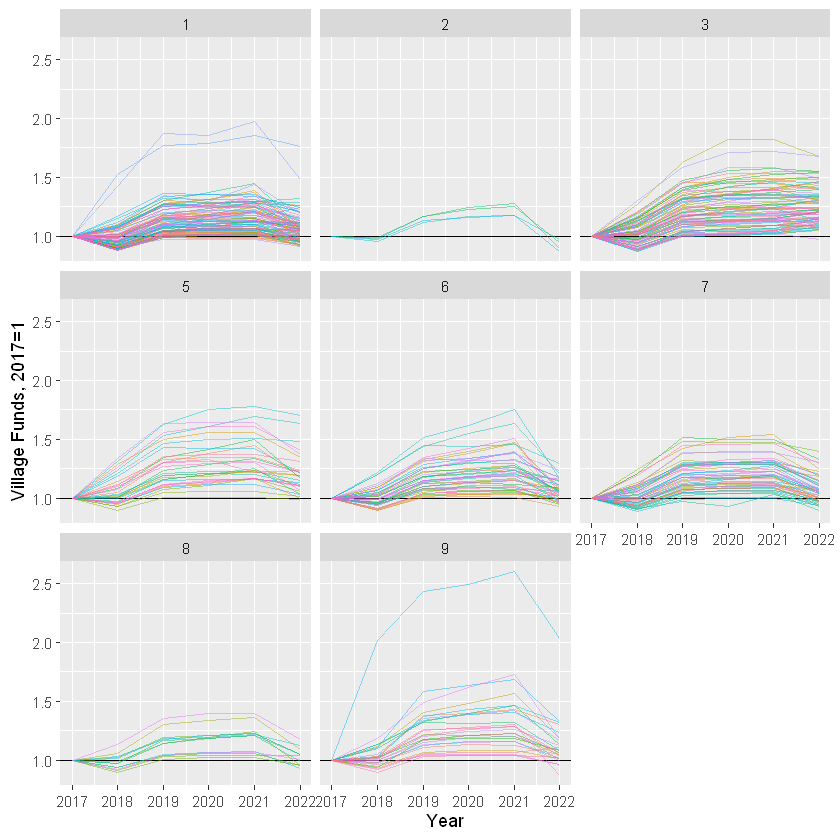

In [11]:
ggplot(sampull %>% mutate(region=substr(prov_2004, 1, 1))) +
  geom_hline(yintercept = 1) +
  geom_line(mapping=aes(x=year, y=normalized_funds, color=as.factor(name_2004)), alpha = 0.45) +
  theme(legend.position="None") +
  facet_wrap("region", ncol=3) +
  xlab("Year") +
  ylab("Village Funds, 2017=1")

In [12]:
ggsave("complete_village_funds_plot.png", width = 20, height = 30, dpi = 300, limitsize = FALSE)

Now a for loop that does all the plots for all the variables mentioned

In [13]:
vars <- list("village_funds", "sp_pop_totl", "na_gdp_inc_og_splc", "na_gdp_agr_splc")

for (var in vars) {
  sampull <- districts_panel %>% filter(!is.na(!!as.symbol(var)) & is_kota_2004==FALSE) %>% #we filter all na values
    arrange(bps_2004, year) %>%
    group_by(bps_2004) %>%
    mutate(normalized_var = !!as.symbol(var) / (!!as.symbol(var))[1]) #normalize

  sampull$normalized_var[is.na(sampull$normalized_var)] <- 0 #replace na values with 0. This is because of division by 0 errors

  plot <- ggplot(sampull %>% mutate(region=substr(prov_2004, 1, 1))) +
    geom_hline(yintercept = 1) +
    geom_line(mapping=aes(x=year, y=normalized_var, color=as.factor(name_2004)), alpha = 0.45) +
    theme(legend.position="None") +
    facet_wrap("region", ncol=3) +
    xlab("Year") +
    ylab(sprintf("%s, normalized to base year=1", var))

  ggsave(sprintf("%s_time_series_plot.png", var), plot)
}

Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
